## Concluding case

Interesting cases that have an h close to 1 km. 

s1b-ew-owi-ca-20210926t090903-20210926t091107-000003-0371EC_sw_al182021_cyclone_polar.nc

rcm2-sclnd-owi-ca-20221022t124742-20221022t124922-00003-xxxxx_sw_ep192022_cyclone_polar.nc

s1a-ew-owi-ca-20230828t223927-20230828t224031-000003-0606CB_sw_al082023_cyclone_polar.nc

In [1]:
# General
import glob
import re
import os.path
# import warnings
# warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm
import copy

# Arrays & Displays
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

# Data treatment
from datetime import datetime
from scipy.optimize import curve_fit
from scipy.interpolate import griddata
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter, binary_dilation

# Default parameters
mpl.rcParams.update({'font.size': 18})
mpl.rcParams['figure.figsize'] = (15, 10)
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.facecolor'] = 'white'

In [28]:
# Paths & Params
PTHS = {
    'dsg_pth':     '/home/arthur/data/tropical_cyclones/SAR/parametric_dataset/dsg.nc',
    'sar_dir':     '/home/arthur/data/tropical_cyclones/SAR/S1_RS2_RCM/sar_files/',
    'sav_dir':     '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/06_CONCLUDING_CASE/',
    'sct_dir':     '/home/arthur/data/tropical_cyclones/scatterometer/hy-2/',
    'dsa_pth':     '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/02_ASYMM_SHEAR_MOTION/dsa.nc',
    # 'K01_PRM_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_LP_KPP_K01/cases/',
    # 'K01_FIT_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_FIT_K01/cases/',
    # 'K01_wIA_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_FIT_K01_wINFLOW_ANGLE/unweighted_rmse/reduced_area_150k/masked_rain/cases/',
    # 'K01_wZU_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_FIT_K01_wZU/unweighted_rmse/reduced_area_150k/cases/',
    'K25_PRM_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_LP_KPP_K25_C1C2FIT/cases/',
    # 'K25_FIT_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_FIT_K25/cases/',
    # 'K25_wIA_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_FIT_K25_wINFLOW_ANGLE/unweighted_rmse/reduced_area_150k/masked_rain/cases/',
    # 'K25_wZU_dir': '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_FIT_K25_wZU/unweighted_rmse/reduced_area_150k/cases/',
    'ZU12_dir':    '/home/arthur/results/TCsLifeMonitFromObs/winddirection/PRJCT_TCBL/00_ZU12/cases/',
}

PRMS = {
    'upper_bound':  150000, # Upper bound for r, in m. Lower bound is Rmax by default.
    'reduced_area': True,  # Constrains the study for Rmax < r < upper_bound
    'sav_fgs': False,
}

# Open data
dsg = xr.open_dataset(PTHS['dsg_pth'])

In [3]:
# FILTERS
cond = (
    # (dsg.lat > 0) &             # Northern hemisphere; Remove this filter?
    (dsg.dist2coast  > dsg.r34) & # Distance to coast
    (dsg.percent_outside < 10)  & # Sufficient SAR coverage
    (dsg.vmx > 20)    
)
dsg_filtered    = dsg.where(cond, drop=True)
print(len(dsg_filtered.time))

606


In [4]:
# Open file
case = dsg_filtered.where(dsg_filtered.name == 'SAM', drop=True).isel(time=1)
file = case.file_tcva.item()
ds   = xr.open_dataset(PTHS['sar_dir'] + file).isel(time=0)

### Plot utils

In [5]:
def coriolis(lat):
    '''Latitude must be in degrees.'''
    Omega = 7.2921e-5                             # Earth rotation vector
    fcor  = 2 * Omega * np.sin(lat * np.pi / 180) # Coriolis parameter assuming it's constant 
    return fcor

def holland_profile(r, lat, B, Vmin, Rmax, Vmax):
    '''We assume that rho is constant and equals 1.15 kg.m-3'''
    fcor   = abs(coriolis(lat))
    rho    = 1.15
    r      = r.astype(float) + 0.001           # To avoid dividing by zero
    r_star = (Rmax / r) ** B
    V      = r * 0.
    V      = Vmin + np.sqrt( ((Vmax - Vmin) ** 2) * r_star * np.exp(1 - r_star) + (r * fcor / 2) ** 2) - (r * fcor / 2)
    return V

#########################
###       PLOT        ###
#########################
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def getColorMap(rgbFile="medspiration.rgb"):
    '''
    Load a RGB palette provided in ascii file
    '''
    colors = []
    nbCol  =0
    for line in open( rgbFile ):
        r,g,b = [int(c) for c in line.split()]
        colors.append( [r/255.,g/255.,b/255.] )
        nbCol += 1
    return(mpl.colors.ListedColormap(colors, name="custom", N=nbCol))

palette      = '/home/arthur/scripts/tools/high_wind_speed.pal'
cwnd         = getColorMap(rgbFile=palette)
normalizer   = Normalize(0, 80)

In [6]:
### Create ref. grid, choose resolution
dim_ref      = np.linspace(-500, 500, int((500 // 1 * 2) + 1)) * 1000
x_ref, y_ref = np.meshgrid(dim_ref, dim_ref)

def pol2cart(r, th):
    x = r * np.cos(th)
    y = r * np.sin(th)
    return x, y

def get_cartesian_wind_from(dss):
    '''Displayed in geographical referential (i.e top is North)'''
    dr, th       = np.meshgrid(dss.rad, dss.theta)
    th           = th + float(dss.rotation_angle) + 90
    th           = np.deg2rad(th % 360)
    ds_x, ds_y   = pol2cart(dr, th)
    ws_car       = griddata((ds_x.flatten(), ds_y.flatten()), np.array(dss.wind_speed.transpose()).flatten(), (x_ref, y_ref), method='nearest')
    return ws_car

def get_storm_oriented_cartesian_wind_from(dss):
    '''Displayed in storm-oriented referential (i.e top is motion direction)'''
    dr, th       = np.meshgrid(dss.rad, dss.theta)
    th           = th + 90 # Convert to polar th, i.e 0° = positive x-axis, 90° = positive y-axis
    th           = np.deg2rad(th % 360)
    ds_x, ds_y   = pol2cart(dr, th)
    ws_car       = griddata((ds_x.flatten(), ds_y.flatten()), np.array(dss.wind_speed.transpose()).flatten(), (x_ref, y_ref), method='nearest')
    return ws_car

In [7]:
### COLORMAP SAR
import sys
import os

# Ajoutez le dossier parent 'my_modules' au chemin de recherche
# Le chemin '..' permet de remonter d'un niveau par rapport à l'emplacement du notebook
module_path = os.path.abspath(os.path.join('../../..', 'tools/'))
print(f"Chemin du module à ajouter : {module_path}")

if module_path not in sys.path:
    sys.path.append(module_path)
    
# Importez la classe CMAP depuis votre script
from cmap_sar import CMAP

# Maintenant, vous pouvez appeler les méthodes de la classe CMAP
cmap_cyclobs, vmin, vmax = CMAP.cyclobs_wind10m(return_vminvmax=True, unit="m/s")
print(f"Colormap créée : {cmap_cyclobs.name}")
print(f"Valeurs min/max : {vmin:.2f} m/s et {vmax:.2f} m/s")
ticks_cyclobs = [5.14444, 17.4911, 25.7222, 32.9244, 42.6989, 49.1433, 58.1, 69.959]

Chemin du module à ajouter : /home/arthur/scripts/tools
Colormap créée : cyclobs_wind10m
Valeurs min/max : 0.00 m/s et 69.96 m/s


In [8]:
def get_cartesian_var_from_kepert(dsk, var):
    dr, th       = np.meshgrid(dsk.rad, dsk.theta)
    th           = np.deg2rad(th + 90 % 360)
    ds_x, ds_y   = pol2cart(dr, th)
    ws_car       = griddata((ds_x.flatten(), ds_y.flatten()), np.array(dsk[var]).flatten(), (x_ref, y_ref), method='nearest')
    return ws_car

alpha = np.arctan2(y_ref, x_ref)
step  = 10

In [9]:
arrow_prms = {
    'scale': 1300,        # À ajuster selon vos données (plus bas = flèches plus longues)
    'width': 0.002,      # Épaisseur du corps de la flèche
    'headwidth': 3,    # Largeur de la pointe
    'headlength': 4,   # Longueur de la pointe
    'pivot': 'middle',   # Centre la flèche sur le point de grille
    'minshaft': 2,     # Longueur minimale
}

### K25 PRM

In [10]:
#########################
### General functions ###
#########################
def coriolis(lat):
    '''Latitude must be in degrees.'''
    Omega = 7.2921e-5                             # Earth rotation vector
    fcor  = 2 * Omega * np.sin(lat * np.pi / 180) # Coriolis parameter assuming it's constant 
    return fcor

def holland_profile(r, lat, B, Vmin, Rmax, Vmax):
    '''We assume that rho is constant and equals 1.15 kg.m-3'''
    fcor   = abs(coriolis(lat))
    rho    = 1.15
    r      = r.astype(float) + 0.001           # To avoid dividing by zero
    r_star = (Rmax / r) ** B
    V      = r * 0.
    V      = Vmin + np.sqrt( ((Vmax - Vmin) ** 2) * r_star * np.exp(1 - r_star) + (r * fcor / 2) ** 2) - (r * fcor / 2)
    return V

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)

#########################
### KEPERT 2025 MODEL ###
#########################
# Inertial stability
def I(Rs, Vs, fcor):
    dr   = np.diff(Rs[0, 0, :])[0] # meters
    ksi  = 2 * Vs / Rs + fcor
    zeta = np.gradient(Vs, dr, axis=2) + Vs / Rs + fcor
    return np.sqrt(ksi * zeta)

# Coefficients
def sqrt_alpha_beta(Rs, Vs, fcor):
    '''Corresponds to sqrt(alpha / beta).'''
    dr   = np.diff(Rs[0, 0, :])[0] # meters
    ksi  = 2 * Vs / Rs + fcor
    zeta = np.gradient(Vs, dr, axis=2) + Vs / Rs + fcor
    return np.sqrt(ksi / zeta)

def eta(Rs, Vs, K, C, fcor):
    return C * Vs * np.sqrt(2 / (K * ((Vs / Rs) + I(Rs, Vs, fcor))))

def ki(Rs, Vs, K, C, fcor):
    return C * Vs * np.sqrt(2 / (K * I(Rs, Vs, fcor)))

def psi(Rs, Vs, K, C, fcor):
    return C * Vs * np.sqrt(2 / (K * abs((Vs / Rs) - I(Rs, Vs, fcor))))

# Amplitudes
def A0(Rs, Vs, K, C, fcor):
    num = -ki(Rs, Vs, K, C, fcor) * Vs * [1 + 1j * (1 + ki(Rs, Vs, K, C, fcor))]
    den = 2 * ki(Rs, Vs, K, C, fcor) ** 2 + 3 * ki(Rs, Vs, K, C, fcor) + 2
    return num / den

def A1(Rs, Vs, K, C, c1, c2, fcor):
    '''Note the error of parenthesis in his Eq. 29 - I re-computed the exact coefficients, the parenthesis should be removed.'''
    # New notations
    ki0  = ki(Rs, Vs, K, C, fcor)
    ki1  = eta(Rs, Vs, K, C, fcor)
    ki_1 = psi(Rs, Vs, K, C, fcor)
    # New expressions
    num  = (c1 - 1j * c2) * ki1 * [(3 + 1j) * ki0 * ki_1 + (2 - 2j) * (ki0 + ki_1) - 4j] * abs(Vs)
    den  = 2 * (2 * ki0 ** 2 + 3 * ki0 + 2) * [(2 + 2j) * (1 + ki1 * ki_1) + 3 * ki1 + 3j * ki_1]
    return num / den

def A_1(Rs, Vs, K, C, c1, c2, fcor):
    '''Note the error of parenthesis in his Eq. 29 - I re-computed the exact coefficients, the parenthesis should be removed.'''
    # New notations
    ki0  = ki(Rs, Vs, K, C, fcor)
    ki1  = eta(Rs, Vs, K, C, fcor)
    ki_1 = psi(Rs, Vs, K, C, fcor)
    # New expressions
    num  = (c1 + 1j * c2) * ki_1 * [(3 + 1j) * ki0 * ki1 + (2 - 2j) * (ki0 + ki1) - 4j] * abs(Vs)
    den  = 2 * (2 * ki0 ** 2 + 3 * ki0 + 2) * [(2 + 2j) * (1 + ki1 * ki_1) + 3 * ki_1 + 3j * ki1]
    return num / den

def A1_prime(Rs, Vs, K, C, c1, c2, fcor):
    # New notations
    ki0  = ki(Rs, Vs, K, C, fcor)
    ki1  = eta(Rs, Vs, K, C, fcor)
    ki_1 = psi(Rs, Vs, K, C, fcor)
    # New expressions
    num  = (c1 - 1j * c2) * ki1 * [(1 - 3j) * ki0 * ki_1 + (2 - 2j) * ki0 - (2 + 2j) * ki_1 - 4j] * abs(Vs)
    den  = 2 * (2 * ki0 ** 2 + 3 * ki0 + 2) * [2 + 2j + 3 * (ki1 + ki_1) + (2 - 2j) * ki1 * ki_1]
    return num / den

def A_1_prime(Rs, Vs, K, C, c1, c2, fcor):
    # New notations
    ki0  = ki(Rs, Vs, K, C, fcor)
    ki1  = eta(Rs, Vs, K, C, fcor)
    ki_1 = psi(Rs, Vs, K, C, fcor)
    # New expressions
    num  = (c1 + 1j * c2) * ki_1 * [1j * (1 - 3j) * ki0 * ki1 + (2 - 2j) * ki0 + (2 + 2j) * ki1 - 4j] * abs(Vs)
    den  = 2 * (2 * ki0 ** 2 + 3 * ki0 + 2) * [2 - 2j + 3 * (ki1 + ki_1) + (2 + 2j) * ki1 * ki_1]
    return num / den

# Thicknesses
def delta0(Rs, Vs, K, fcor):
    return np.sqrt(2 * K / abs(I(Rs, Vs, fcor)))

def delta1(Rs, Vs, K, fcor):
    return np.sqrt(2 * K / abs(I(Rs, Vs, fcor) + Vs / Rs))

def delta_1(Rs, Vs, K, fcor):
    return np.sqrt(2 * K / abs(I(Rs, Vs, fcor) - Vs / Rs))

# Radial and tangential wind components
def u0(Rs, Vs, K, C, fcor, zi, z_ref):
    u0 = sqrt_alpha_beta(Rs, Vs, fcor) * np.real(A0(Rs, Vs, K, C, fcor) * np.exp(- (1 + 1j) * (zi - z_ref) / delta0(Rs, Vs, K, fcor)))
    return np.reshape(u0,  np.shape(u0)[1:])

def v0(Rs, Vs, K, C, fcor, zi, z_ref):
    v0 = np.imag(A0(Rs, Vs, K, C, fcor) * np.exp(- (1 + 1j) * (zi - z_ref) / delta0(Rs, Vs, K, fcor)))
    return np.reshape(v0,  np.shape(v0)[1:])

def u1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    u1        = Vs * 0
    msk       = I(Rs, Vs, fcor) >= Vs / Rs
    if_msked  = sqrt_alpha_beta(Rs, Vs, fcor) * np.real(A1(Rs, Vs, K, C, c1, c2, fcor)       * np.exp(- (1 + 1j) * (zi - z_ref) / delta1(Rs, Vs, K, fcor) + 1j * h * THs))
    otherwise = sqrt_alpha_beta(Rs, Vs, fcor) * np.real(A1_prime(Rs, Vs, K, C, c1, c2, fcor) * np.exp(- (1 + 1j) * (zi - z_ref) / delta1(Rs, Vs, K, fcor) + 1j * h * THs))
    u1[msk]   = np.reshape(if_msked,  np.shape(if_msked)[1:])[msk]
    u1[~msk]  = np.reshape(otherwise, np.shape(if_msked)[1:])[~msk]
    return u1

def v1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    v1        = Vs * 0
    msk       = I(Rs, Vs, fcor) >= Vs / Rs
    if_msked  = np.imag(A1(Rs, Vs, K, C, c1, c2, fcor)       * np.exp(- (1 + 1j) * (zi - z_ref) / delta1(Rs, Vs, K, fcor) + 1j * h * THs))
    otherwise = np.imag(A1_prime(Rs, Vs, K, C, c1, c2, fcor) * np.exp(- (1 + 1j) * (zi - z_ref) / delta1(Rs, Vs, K, fcor) + 1j * h * THs))
    v1[msk]   = np.reshape(if_msked,  np.shape(if_msked)[1:])[msk]
    v1[~msk]  = np.reshape(otherwise, np.shape(if_msked)[1:])[~msk]
    return v1

def u_1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    u1        = Vs * 0
    msk       = I(Rs, Vs, fcor) >= Vs / Rs
    if_msked  = sqrt_alpha_beta(Rs, Vs, fcor) * np.real(A_1(Rs, Vs, K, C, c1, c2, fcor)       * np.exp(- (1 + 1j) * (zi - z_ref) / delta_1(Rs, Vs, K, fcor) - 1j * h * THs))
    otherwise = sqrt_alpha_beta(Rs, Vs, fcor) * np.real(A_1_prime(Rs, Vs, K, C, c1, c2, fcor) * np.exp(- (1 - 1j) * (zi - z_ref) / delta_1(Rs, Vs, K, fcor) - 1j * h * THs))
    u1[msk]   = np.reshape(if_msked,  np.shape(if_msked)[1:])[msk]
    u1[~msk]  = np.reshape(otherwise, np.shape(if_msked)[1:])[~msk]
    return u1

def v_1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    v1        = Vs * 0
    msk       = I(Rs, Vs, fcor) >= Vs / Rs
    if_msked  = np.imag(A_1(Rs, Vs, K, C, c1, c2, fcor)       * np.exp(- (1 + 1j) * (zi - z_ref) / delta_1(Rs, Vs, K, fcor) - 1j * h * THs))
    otherwise = np.imag(A_1_prime(Rs, Vs, K, C, c1, c2, fcor) * np.exp(- (1 - 1j) * (zi - z_ref) / delta_1(Rs, Vs, K, fcor) - 1j * h * THs))
    v1[msk]   = np.reshape(if_msked,  np.shape(if_msked)[1:])[msk]
    v1[~msk]  = np.reshape(otherwise, np.shape(if_msked)[1:])[~msk]
    return v1

# TOTAL WIND COMPONENTS IN THE BL
def u_BL(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    # print(np.shape(THs), np.shape(zi), np.shape(z_ref))
    # Vs_dyd = np.concatenate((np.stack([np.ones(np.argmax(Vs)) for i in range(np.shape(Vs)[0])]) * Vs[0, 0], Vs), axis=1)[:, :np.shape(Vs)[1]]
    # return u_1(THs, Rs, Vs_dyd, K, C, c1, c2, fcor, zi, z_ref, h) + u0(Rs, Vs, K, C, fcor, zi, z_ref) + u1(THs, Rs, Vs_dyd, K, C, c1, c2, fcor, zi, z_ref, h)
    return u_1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h) + u0(Rs, Vs, K, C, fcor, zi, z_ref) + u1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h)

def v_BL(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    # Vs_dyd = np.concatenate((np.stack([np.ones(np.argmax(Vs)) for i in range(np.shape(Vs)[0])]) * Vs[0, 0], Vs), axis=1)[:, :np.shape(Vs)[1]]
    # return Vs + v_1(THs, Rs, Vs_dyd, K, C, c1, c2, fcor, zi, z_ref, h) + v0(Rs, Vs, K, C, fcor, zi, z_ref) + v1(THs, Rs, Vs_dyd, K, C, c1, c2, fcor, zi, z_ref, h)
    return Vs + v_1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h) + v0(Rs, Vs, K, C, fcor, zi, z_ref) + v1(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h)

# FINAL MODEL
def kepert2025(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h):
    # Returns Kepert wind speeds
    u_K25   = u_BL(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h)
    v_K25   = h * v_BL(THs, Rs, Vs, K, C, c1, c2, fcor, zi, z_ref, h)  

    # Not for K25!!!
    # # Adds the translation speed
    # Utu     = Ut * np.cos(THs) # Radial component of Ut
    # Utv     = -Ut * np.sin(THs) # Tangential component of Ut
    # # Utu = Utv = 0
    
    # return u_K25 + Utu, v_K25 + Utv
    return u_K25, v_K25

#########################
### CREATE STRUCTURES ###
#########################
def get_xrDataset_polar(zs, ths, rs, u_K25, v_K25):
    kep_pol = xr.Dataset(
        data_vars={
            'wind_speed': (('z', 'theta', 'rad'), np.sqrt(np.array(v_K25) ** 2 + np.array(u_K25) ** 2)),
            'rad_wind':   (('z', 'theta', 'rad'), np.array(u_K25)),
            'tan_wind':   (('z', 'theta', 'rad'), np.array(v_K25)),
        },
        coords={
            'z': zs,
            'theta': np.rad2deg(ths),
            'rad': rs,
        }
    )
    kep_pol['inflow_angle'] = np.rad2deg(np.arctan((kep_pol.rad_wind / kep_pol.tan_wind))) # Inflow Angle Polar
    return kep_pol

def get_xrDataset_cartesian(Xs, Ys, x_ref, y_ref, dim_ref, kep_pol):
    KEP_CARS = []
    for z in tqdm(zs): # Takes ~20 seconds
        kep_car = xr.Dataset(
            data_vars={
                'wind_speed':   (('y', 'x'), griddata((Xs[0, :, :].flatten(), Ys[0, :, :].flatten()), np.array(kep_pol.sel(z=z).wind_speed).flatten(),   (x_ref, y_ref), method='nearest')),
                'rad_wind':     (('y', 'x'), griddata((Xs[0, :, :].flatten(), Ys[0, :, :].flatten()), np.array(kep_pol.sel(z=z).rad_wind).flatten(),     (x_ref, y_ref), method='nearest')),
                'tan_wind':     (('y', 'x'), griddata((Xs[0, :, :].flatten(), Ys[0, :, :].flatten()), np.array(kep_pol.sel(z=z).tan_wind).flatten(),     (x_ref, y_ref), method='nearest')),
                'inflow_angle': (('y', 'x'), griddata((Xs[0, :, :].flatten(), Ys[0, :, :].flatten()), np.array(kep_pol.sel(z=z).inflow_angle).flatten(), (x_ref, y_ref), method='nearest')),
            },
            coords={
                'x': dim_ref,
                'y': dim_ref,
            }
        )
        KEP_CARS.append(kep_car)
    kep_car = xr.concat(KEP_CARS, 'z').assign_coords({'z': zs})
    return kep_car

### Get vertical velocity estimates
# For the expression see e.g Ueno and Kunii 2009
def get_w(kep_pol, kep_car, zs):
    # Compute vertical velocity by integrating continuity equation
    dru_dr = (kep_pol.rad * kep_pol.rad_wind).differentiate('rad') # d(ru)/dr
    dv_dth = kep_pol.tan_wind.differentiate('theta') / (2 * np.pi / 360) # dv/dtheta, dtheta converted in radians here
    # dv_dth = kep_pol.tan_wind.differentiate('theta')               # dv/dtheta
    WS_POL = []
    WS_CAR = []
    for z in tqdm(zs):
        integral = (dru_dr + dv_dth).sel(z=slice(None, z)).integrate('z')
        w_pol    = - (1 / integral.rad) * integral
        WS_POL.append(w_pol)
        w_car = griddata((Xs[0, :, :].flatten(), Ys[0, :, :].flatten()), np.array(w_pol.transpose()).flatten(), (x_ref, y_ref), method='nearest')
        WS_CAR.append(xr.DataArray(w_car, dims=('y', 'x'), coords={'y': dim_ref, 'x': dim_ref}))
    kep_pol['w'] = xr.concat(WS_POL, dim='z')
    kep_car['w'] = xr.concat(WS_CAR, dim='z')
    return kep_pol, kep_car

#########################
###   MODEL FITTING   ###
#########################
def wind_reduction_factor(Rs, Vs, K, C, fcor):
    '''wrf = surface azim. wind / gradient azim. wind'''
    ki_cst  = ki(Rs, Vs, K, C, fcor)
    num     = ki_cst ** 2 + 2 * ki_cst + 2
    den     = 2 * ki_cst ** 2 + 3 * ki_cst + 2
    return num / den

def wn1(thetas, a, phi, c):
    return a * np.cos(thetas + phi) + c

def get_wn1(thetas, wind_speed, initial_condition=15, upper_bound=80):
    '''
    initial_condition: initial conidition for the amplitude and the constant c (just put Vplus)
    upper_bound: upper bound for the the amplitude and the constant c (just put Vmax)
    '''
    # Fitting process
    popt, pcov = curve_fit(
        f=wn1,
        xdata=thetas,
        ydata=wind_speed,
        p0=[initial_condition, np.pi / 2, initial_condition],
        bounds=([1., -2 * np.pi, 0.1], [upper_bound, 2 * np.pi, upper_bound]) # ([lower bounds], [upper bounds])
    )
    a, phi, c = popt[0], popt[1], popt[2]
    return a, phi, c

def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

#########################
###       PLOT        ###
#########################
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def getColorMap(rgbFile="medspiration.rgb"):
    '''
    Load a RGB palette provided in ascii file
    '''
    colors = []
    nbCol  = 0
    for line in open( rgbFile ):
        r,g,b = [int(c) for c in line.split()]
        colors.append( [r/255.,g/255.,b/255.] )
        nbCol += 1
    return(mpl.colors.ListedColormap(colors, name="custom", N=nbCol))

palette = '/home/arthur/scripts/tools/high_wind_speed.pal'
cwnd         = getColorMap(rgbFile=palette)
normalizer   = Normalize(0, 80)

In [11]:
### FUNCTIONS TO COMPUTE ASYMMETRY AMPLITUDE
### FITS HOLLAND AT EACH RADIUS

def initialize_radius(spdm):
    '''Given the spdm, returns the largest radius (and asociated spdm) on which the profile can be fitted. 
    Indeed, sometimes the spdm isn't defined from r = 0 to r = 500, in this case the largest domain is taken instead.'''
    # Initialize first and last indexes
    first_valid_index = 0
    last_valid_index  = len(spdm)
    r                 = np.arange(last_valid_index) # to avoid having both r = 0 and n < 0 during fitting process
    
    ### Lower bound
    # We change it if spdm[0] = nan
    if np.isnan(spdm[0]):
        first_valid_index = np.min(np.where(np.isfinite(spdm)))
        
    ### Upper bound
    # We change it if there is a nan somewhere
    if np.isnan(np.min(spdm[first_valid_index:])):
        last_valid_index  = np.min(np.where(np.isnan(spdm[first_valid_index:]))[0]) # returns the index of the last valid value before the first nan
        last_valid_index += first_valid_index - 1
        
    # Define r and spdm
    r    = r[first_valid_index:last_valid_index] * 1000
    spdm = spdm[first_valid_index:last_valid_index]
    
    return r, spdm

# Test - Compute asymmetry by computing an average Holland per theta slice to smooth all the noise
BDS_HOL = {
    'B':      [0.01, 3.],
    'Vmin':   [0, 50],
    'Rmax':   [5 * 1000, 500 * 1000],
    'Vmax':   [10, 100],   
}

# Define the steps
# TODO: I could refine how I choose these steps to make them more continuous
# th_steps = np.linspace(0, 340, 341)
th_steps = np.linspace(0, 360, 19)[:-1] # Slice of 20 degrees
th_delta = 20 # degrees

In [12]:
def get_rmse_wrt_sar_fixedKC(optim_params, K, C, THs_sar, Rs_sar, Zs_sar, ths, rs, zs_sar, Vs_sar, fcr, z_ref, h, dsp_sar):
    # Extraire les paramètres à optimiser
    c1, c2 = optim_params

    # Wind at gradient level
    wrf        = wind_reduction_factor(Rs_sar, Vs_sar, K, C, fcr) # azimuthal wind
    Vs_try_sar = Vs_sar / wrf

    # Get K25
    u_K25, v_K25 = kepert2025(THs_sar, Rs_sar, Vs_try_sar, K, C, c1, c2, fcr, Zs_sar, z_ref, h)

    # Get polar dataset
    kep_pol      = get_xrDataset_polar(zs_sar, ths, rs, u_K25, v_K25)

    return float(rmse(kep_pol.interp(coords={'rad': np.array(dsp_sar.wind_speed.transpose().rad)}).sel(theta=slice(0, 359)).wind_speed, dsp_sar.wind_speed.transpose()))

In [13]:
#########################
###  HYPERPARAMETERS  ###
#########################
### Reference grids
rs            = np.linspace(1000, 5e5, 500)
ths           = np.linspace(0, 2 * np.pi, 361)                           # in radians
zs            = np.array([10, 110, 210, 310, 510, 1010, 1510, 2010])     # in meters
Rs, THs       = np.meshgrid(rs, ths)                                     # shape (361, 5000)

# Vectorize on dim z
THs           = np.repeat(np.expand_dims(THs, axis=0), len(zs),  axis=0) # shape e.g (len(zs), 361, 5000)
Rs            = np.repeat(np.expand_dims(Rs,  axis=0), len(zs),  axis=0) # shape e.g (len(zs), 361, 5000)
Zs            = np.repeat(np.expand_dims(zs,  axis=1), len(ths), axis=1) # shape e.g (len(zs), 361, 5000)
Zs            = np.repeat(np.expand_dims(Zs,  axis=2), len(rs),  axis=2) # shape e.g (len(zs), 361, 5000)

# To create cartesian dataset
Xs, Ys        = pol2cart(Rs, THs)                                        # to create cartesian dataset
dim_ref       = np.linspace(-500, 500, int((500 // 1 * 2) + 1)) * 1000   # to create cartesian dataset
x_ref, y_ref  = np.meshgrid(dim_ref, dim_ref)                            # to create cartesian dataset

# To compute asymmetries
xs            = np.linspace(1000, 250000, 250)

# Ref. height
z_ref         = 10

# Fitting values
initial_guess = [0.1, 0.1] 
bounds        = [(-10., 10.), (-10., 10.)] # (min, max) pour chaque paramètre; Use the same boundaries for all!!!

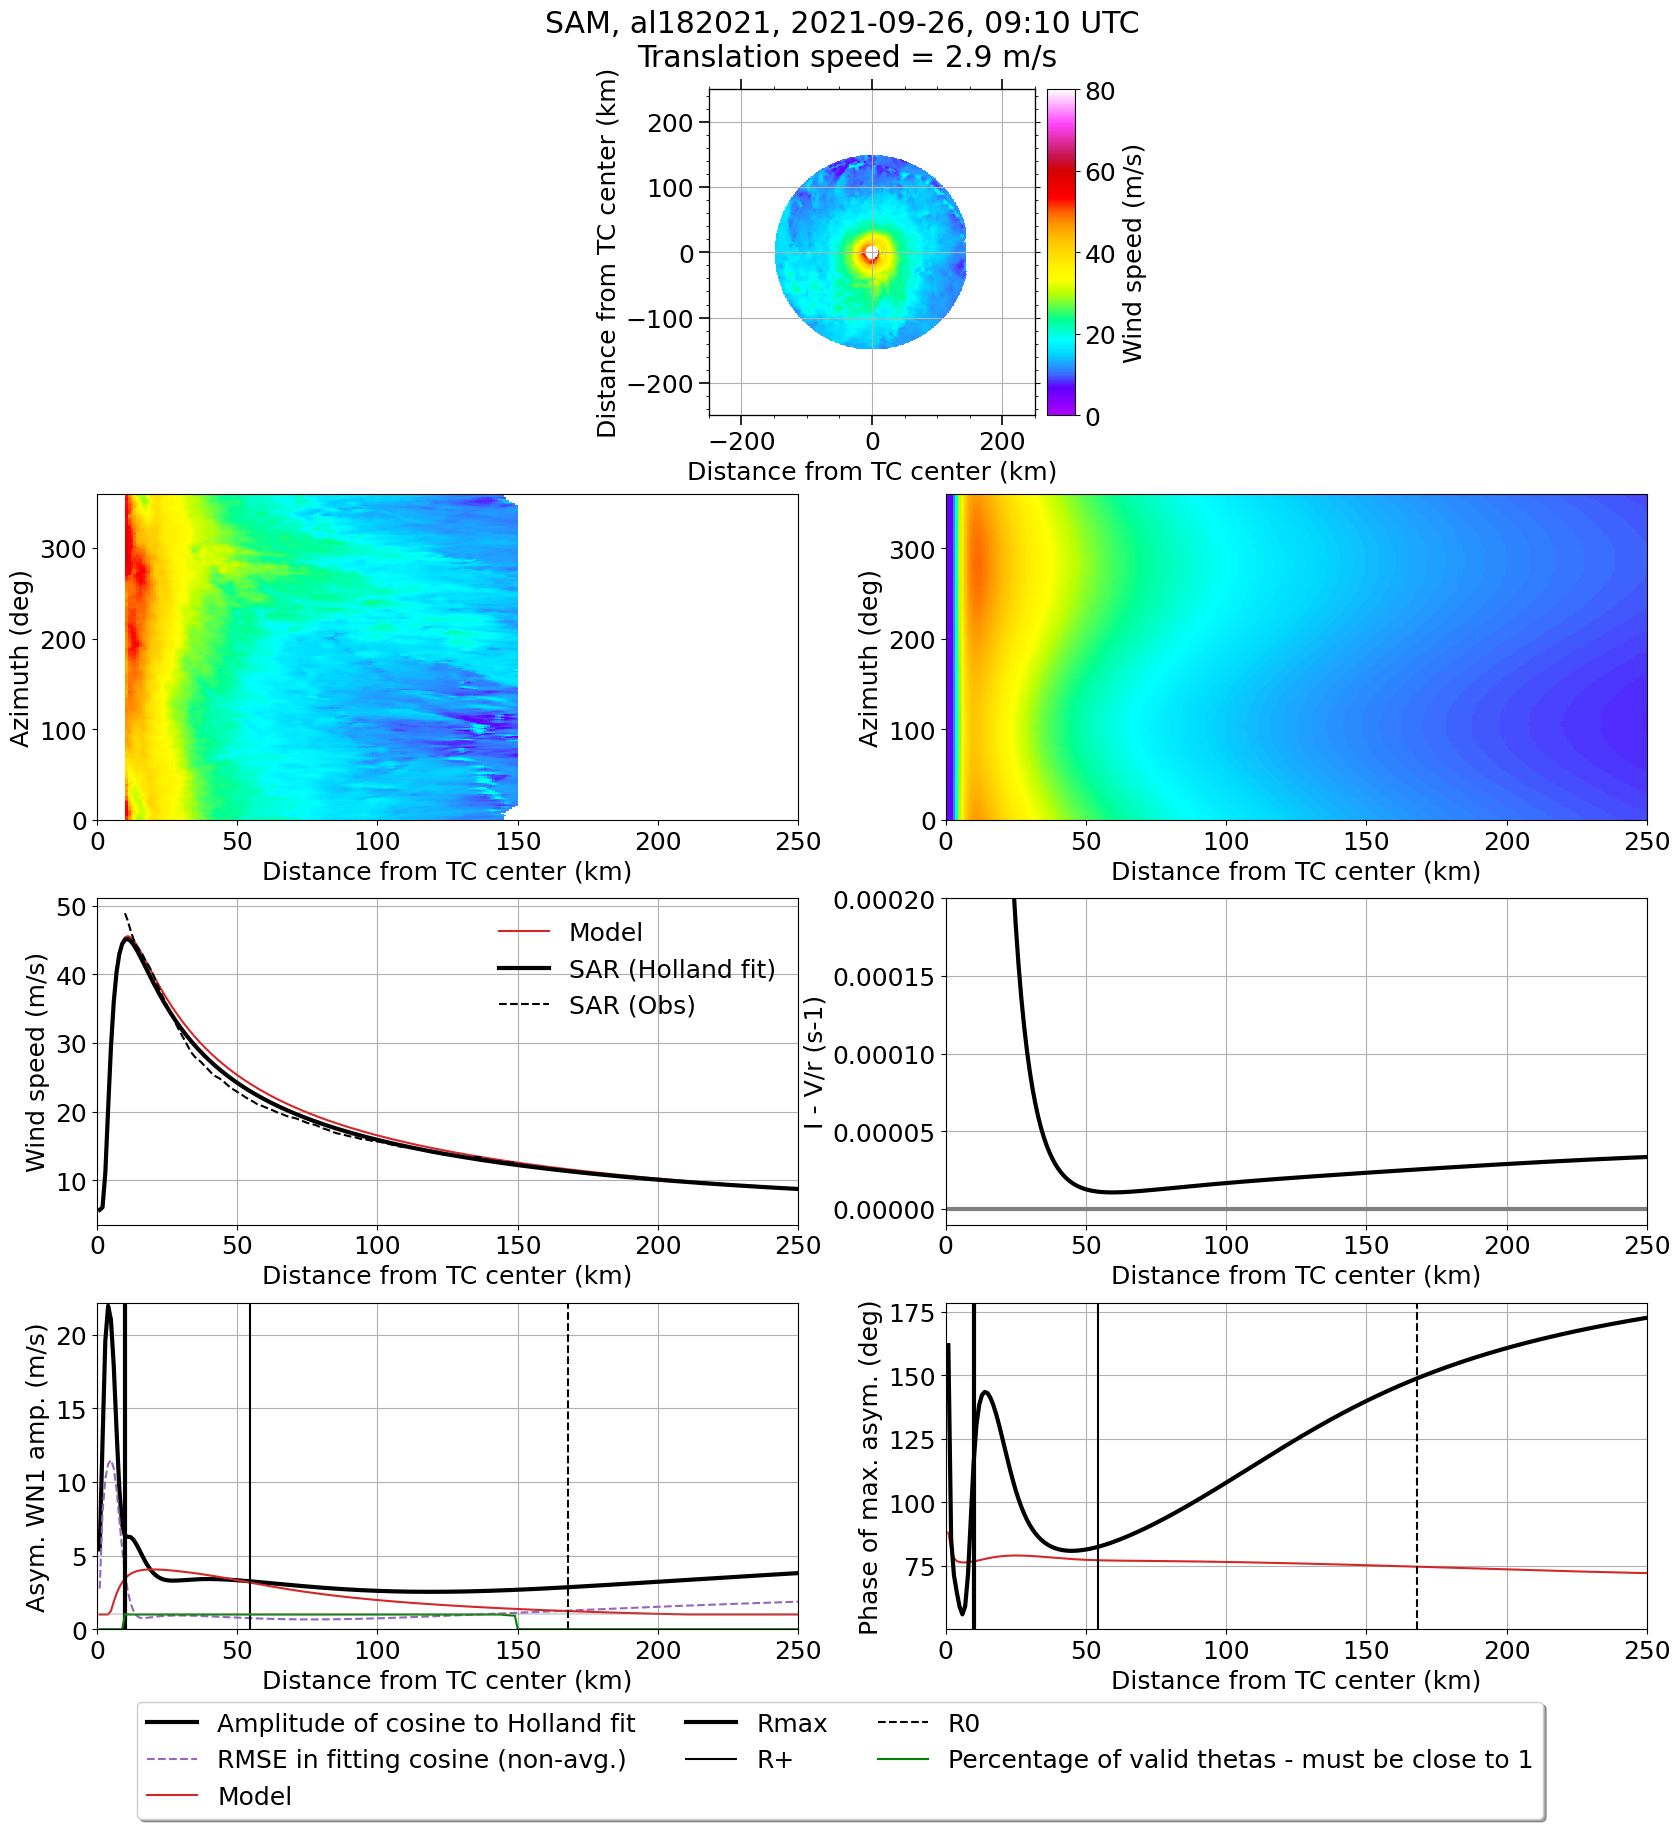

In [14]:
# Reduced area (Optional)
if PRMS['reduced_area']:
    ds    = ds.where((ds.rad >= float(case.rmx))    & (ds.rad < float(PRMS['upper_bound'])))

# Determined parameters
vmx = float(case.vmx_hol)
rmx = float(case.rmx_hol)
vmn = float(case.vmn_hol)
B   = float(case.B_hol)
lat = float(case.lat)
fcr = abs(float(case.fcor))
Ut  = float(case.speed)

# Holland
V    = holland_profile(rs, lat, B, vmn, rmx, vmx)
Vs   = np.stack([V for i in range(np.shape(THs)[1])]) # Shape (361, 5000)
Vs   = np.repeat(np.expand_dims(Vs, axis=0), len(zs), axis=0)

# Sign due to hemisphere
h    = 1 if lat > 0 else -1

#############################
### TURBULENT PARAMETERS  ###
#############################
cd_lp          = np.ones_like(V) * 1e-3 # Large and Pond
K_kpp          = np.ones_like(V)        # KPP

rmax_to_r0     = (rs >= float(case.rmx)) & (rs <= float(case.r0))

try:
    ### C - Large and Pond formulation, averaged (cylindrical)
    # For V > 10.92 m/s
    cd_lp[V <= 10.92] = 1.2e-3 # We use 10.92 instead of 11 to ensure continuity of Cd
    low_ws            = (V > 10.92)
    cd_lp[low_ws]     = (0.49 + 0.065 * V[low_ws]) * 1e-3
    # For V > 38.62 m/s
    hgh_ws            = (V > 38.62)
    cd_lp[hgh_ws]     = 3 * 1e-3
    # Cylindrical average
    cd_mean_lp        = 2 * np.trapezoid(cd_lp[rmax_to_r0] * rs[rmax_to_r0], rs[rmax_to_r0]) / (float(case.r0 - case.rmx) ** 2)

    ### K - KPP formulation, averaged (cylindrical)
    # K_kpp      = (0.25 / 12) * 0.4 * 500 * (V ** 2) * np.sqrt(cd_lp) + 10 * 0.4 * V * np.sqrt(cd_lp)
    # K_kpp      = (0.25 / 12) * 0.4 * 500  * V * np.sqrt(cd_lp) + 10 * 0.4 * V * np.sqrt(cd_lp) # h = 500m and H = 2km                         
    K_kpp      = (0.5 / 12) * 0.4 * 1000 * V * np.sqrt(cd_lp) + 10 * 0.4 * V * np.sqrt(cd_lp) # h = 1km and H = 2km
    K_mean_kpp = 2 * np.trapezoid(K_kpp[rmax_to_r0] * rs[rmax_to_r0], rs[rmax_to_r0]) / (float(case.r0 - case.rmx) ** 2)
    
except IndexError:
    cd_mean_lp = K_mean_kpp = np.nan

case['cd_mean_lp'] = cd_mean_lp
case['K_mean_kpp'] = K_mean_kpp

############
### Fit  ###
############
# Fitting
fixed_args    = (K_mean_kpp, cd_mean_lp, THs, Rs, Zs, ths, rs, zs, Vs, fcr, z_ref, h, ds)
result        = minimize(get_rmse_wrt_sar_fixedKC, initial_guess, args=fixed_args, method='L-BFGS-B', bounds=bounds) # Takes less than 30 seconds

# Extract result
if result.success:
    c1_opt, c2_opt = result.x
else:
    print('Optimisation failed for t = {}'.format(t))
    print(result.message)
    c1_opt = c2_opt = np.nan

# Assign
case['c1_K25']      = c1_opt
case['c2_K25']      = c2_opt

if result.success:
    #####################
    ### Extract. sol. ###
    #####################
    # Wind at gradient level
    wrf    = wind_reduction_factor(Rs, Vs, K_mean_kpp, cd_mean_lp, fcr) # azimuthal wind
    Vs_try = Vs / wrf
    
    # Get K25
    u_K25, v_K25 = kepert2025(THs, Rs, Vs_try, K_mean_kpp, cd_mean_lp, c1_opt, c2_opt, fcr, Zs, z_ref, h)
    
    # Get polar dataset
    kep_pol      = get_xrDataset_polar(zs, ths, rs, u_K25, v_K25)
    
    # Compute asymmetries on Kepert wind field
    aks         = []
    pks         = []
    # Iterate over all radii
    for rad in xs: # Iterate only in the valid range to optimize time
        try:
            ak, phi, _  = get_wn1(np.deg2rad(kep_pol.sel(z=10).theta), kep_pol.sel(z=10).wind_speed.sel(rad=rad, method='nearest'), np.max(Vs[0, 0, :]) / 3, np.max(Vs[0, 0, :]))
        except RuntimeError:
            ak = phi = np.nan
        aks.append(ak)
        pks.append(phi)

    # Non-C1 points?
    I__V_r       = I(Rs, Vs_try, fcr)[0, :, :].mean(axis=0) - Vs_try[0, :, :].mean(axis=0) / rs
    case['non_C1'] = (np.count_nonzero(I__V_r[rs >= rmx] < 0) > 0)
    
    #################
    ### SAR asym. ###
    #################
    # Initialize
    LWS = [] # To save the Holland wind speeds
    ERR = [] # To compute RMSE
    ACN = [] # Amplitude of cosine
    PHS = [] # Phase of cosine
    VTS = [] # Nb of valid thetas

    # Fit Holland for each theta
    for th in th_steps:
        ds_slice          = ds.sel(theta=slice(th, th + th_delta))
        wsm               = ds_slice.wind_speed.mean(dim='theta', skipna=True)
        r_crop, spdm_crop = initialize_radius(np.array(wsm))
    
        try:
            # Holland
            popt, pcov = curve_fit(
                lambda r, B, Vmin, Rmax, Vmax: holland_profile(r, lat, B, Vmin, Rmax, Vmax), 
                np.array(r_crop), 
                np.array(spdm_crop), 
                p0=[1.8, 5, 20 * 1000, 40], 
                bounds=(
                    tuple([BDS_HOL[e][0] for e in BDS_HOL.keys()]), # NB: lat is fixed
                    tuple([BDS_HOL[e][1] for e in BDS_HOL.keys()])
                ) 
            ) 
            B_hol, vmn_hol, rmx_hol, vmx_hol = popt
            
        except (RuntimeError, ValueError):
            B_hol = vmn_hol = rmx_hol = vmx_hol = np.nan
        
        # Append
        LWS.append(holland_profile(rs, lat, B_hol, vmn_hol, rmx_hol, vmx_hol))

    # Create dataset with Holland for each theta
    dsh = xr.Dataset(
        data_vars={
            'ws':        (('th', 'rad'), LWS),
        },
        coords={
            'th': th_steps,
            'rad': rs,
        }
    )
    
    # Compute asymmetries
    for rad in xs:
        # Amplitude of cosine
        if np.count_nonzero(np.isnan(dsh.sel(rad=rad, method='nearest').ws)) == 0:
            try:
                acn, phi, c = get_wn1(np.deg2rad(dsh.sel(rad=rad, method='nearest').th), dsh.sel(rad=rad, method='nearest').ws, float(case.vmx) / 3, float(case.vmx))
            except RuntimeError:
                acn = phi = c = np.nan
        else:
            acn = phi = c = np.nan
        ACN.append(acn)
        PHS.append(phi)
        # Error
        error         = float(rmse(dsh.sel(rad=rad, method='nearest').ws, wn1(np.deg2rad(dsh.th), acn, phi, c))) 
        ERR.append(error)
        # Valid thetas
        VTS.append(len(ds.sel(rad=rad, method='nearest').dropna(subset=['wind_speed'], dim='theta').theta))

    ### Validation metrics
    # Asymmetry amplitude metrics
    case['max_asym_sar']  = np.nanmax(np.array(ACN)[xs >= rmx])
    case['max_asym_K25']  = np.nanmax(np.array(aks)[xs >= rmx])
    case['asym_avg_err']  = rmse(np.array(aks)[xs >= rmx], np.array(ACN)[xs >= rmx])
    # Asymmetry phase metrics
    a_sar               = (np.rad2deg(PHS) % 360)[xs >= rmx]
    a_K25               = (np.rad2deg(pks) % 360)[xs >= rmx]
    case['phase_avg_err'] = np.nanmean(np.minimum(abs(a_sar - a_K25), 360 - abs(a_sar - a_K25)))

    ############
    ### Plot ###
    ############
    fig          = plt.figure(figsize=(20, 20))
    gs           = GridSpec(4, 2, hspace=0.24, wspace=0.21)
    cmap         = plt.get_cmap('PuOr') # Spectral
    normalizer   = Normalize(0, 80)
    ax_lims      = 250
    ts           = pd.to_datetime(str(case.time.values)) 
    d            = ts.strftime('%Y-%m-%d, %H:%M')
    plt.suptitle('{}, {}, {} UTC \nTranslation speed = {:.1f} m/s'.format(case.name.item(), case.id.item(), d, case.speed), y=0.92)
    
    ### Plot SAR
    ax           = fig.add_subplot(gs[0, :])
    dr, th       = np.meshgrid(ds.rad, np.deg2rad(ds.theta))
    ds_x, ds_y   = pol2cart(dr, th)
    ws_car       = griddata((ds_x.flatten(), ds_y.flatten()), np.array(ds.wind_speed.transpose()).flatten(), (x_ref, y_ref), method='linear')
    im           = ax.pcolormesh(x_ref / 1000, y_ref / 1000, ws_car, cmap=cwnd, norm=normalizer)
    
    # Axes
    ax.set_xlim(-ax_lims, ax_lims);ax.set_ylim(-ax_lims, ax_lims)
    ax.set_ylabel(r'Distance from TC center (km)')
    ax.set_xlabel(r'Distance from TC center (km)')
    # ax.set_box_aspect(1)
    ax.minorticks_on()
    ax.tick_params(length=7, width=1.2)
    ax.grid()
    
    ax2 = ax.twinx().twiny() 
    ax2.set_xlim(-ax_lims, ax_lims);ax2.set_ylim(-ax_lims, ax_lims)
    ax2.minorticks_on()
    ax2.tick_params(axis='both', length=7, width=1.2)
    ax2.set_box_aspect(1)
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    
    # Colorbar
    cb_ax = fig.add_axes([0.6, 0.717, 0.014, 0.163])
    cbar  = fig.colorbar(im, cax=cb_ax)
    cbar.set_label(r'Wind speed (m/s)', rotation=90)
    cbar.ax.get_yaxis().labelpad=5
    
    ### Plot wind field SAR
    ax       = fig.add_subplot(gs[1, 0])
    ax.pcolormesh(ds.wind_speed.transpose(), cmap=cwnd, norm=normalizer)
    ax.set_xlabel(r'Distance from TC center (km)')
    ax.set_ylabel(r'Azimuth (deg)')
    ax.set_xlim(0, ax_lims)
    
    ### Plot wind field Kepert
    ax       = fig.add_subplot(gs[1, 1])
    ax.pcolormesh(Rs[0, :, :] / 1000, np.rad2deg(THs[0, :, :]), kep_pol.sel(z=10).wind_speed, cmap=cwnd, norm=normalizer)
    ax.set_xlabel(r'Distance from TC center (km)')
    ax.set_ylabel(r'Azimuth (deg)')
    ax.set_xlim(0, ax_lims)
    
    ### Plot wind profiles (SAR + Kepert)
    ax       = fig.add_subplot(gs[2, 0])
    ax.plot(rs / 1000,  kep_pol.sel(z=10).wind_speed.mean(dim='theta'), c='tab:red', label='Model')
    ax.plot(rs / 1000,  Vs[0, 0, :], c='k', linewidth=3, label='SAR (Holland fit)')
    ax.plot(ds.rad / 1000, ds.wind_speed.mean(dim='theta'), c='k', linestyle='dashed', label='SAR (Obs)')
    ax.legend(frameon=False)
    ax.set_xlabel(r'Distance from TC center (km)')
    ax.set_ylabel(r'Wind speed (m/s)')
    ax.set_xlim(0, ax_lims)
    ax.grid()
    
    ### Plot conditional curves to highlight non-C1 points
    ax       = fig.add_subplot(gs[2, 1])
    ax.plot(rs / 1000, I__V_r, c='k', linewidth=3)
    ax.axhline(0, c='gray', linewidth=3)
    ax.set_xlabel(r'Distance from TC center (km)')
    ax.set_ylabel(r'I - V/r (s-1)')
    ax.set_xlim(0, ax_lims)
    ax.set_ylim(-0.00001, 0.0002)
    ax.grid()
    
    ### Plot asymmetries (SAR + Kepert)
    ax       = fig.add_subplot(gs[3, 0])
    
    ax.plot(xs / 1000, ACN, c='k', linewidth=3,                 label='Amplitude of cosine to Holland fit')
    ax.plot(xs / 1000, ERR, c='tab:purple', linestyle='dashed', label='RMSE in fitting cosine (non-avg.)')
    # Kepert asymmetry profiles
    ax.plot(xs / 1000, aks,                 c='tab:red',                        label='Model')
    # Wind radii
    ax.axvline(case.rmx / 1000,                      c='k',    linewidth=3,        label='Rmax')
    ax.axvline(case.rps / 1000,                      c='k',                        label='R+')
    ax.axvline(case.r0 / 1000,                       c='k',    linestyle='dashed', label='R0')
    
    # Validity curves
    ax.plot(xs / 1000, np.array(VTS) / 360., c='green',                          label='Percentage of valid thetas - must be close to 1')
    # ax.plot(xs / 1000, Ut / Vs[0, idxs],      c='green',      linestyle='dashed', label='Ut / V - must remain small')
    ax.axhline(1, c='gray', alpha=0.3)
    
    # Legends
    ax.set_xlabel(r'Distance from TC center (km)')
    ax.set_ylabel('Asym. WN1 amp. (m/s)')
    ax.legend(loc='lower center', bbox_to_anchor=(1.06, -0.62), ncol=3, fancybox=True, shadow=True)
    # ax.set_xlim(0, max(float(case.r0 / 1000) + 5, 250))
    ax.set_xlim(0, ax_lims)
    ax.set_ylim(0, 0.2 + float(np.nanmax([max(ACN), max(ERR), np.nanmax(aks)])))
    ax.grid()
    
    ### Phase of max. asymmetry
    ax       = fig.add_subplot(gs[3, 1])
    ax.plot(xs / 1000,  np.rad2deg(pks) % 360, c='tab:red', label='Model')
    ax.plot(xs / 1000,  np.rad2deg(PHS) % 360, c='k', linewidth=3, label='SAR')
    ax.axvline(case.rmx / 1000,    c='k', linewidth=3)
    ax.axvline(case.rps / 1000,    c='k')
    ax.axvline(case.r0  / 1000,    c='k', linestyle='dashed')
    # ax.legend(frameon=False)
    ax.set_xlabel(r'Distance from TC center (km)')
    ax.set_ylabel(r'Phase of max. asym. (deg)')
    ax.set_xlim(0, ax_lims)
    ax.grid()

In [15]:
### Get cartesian dataset
kep_car = get_xrDataset_cartesian(Xs, Ys, x_ref, y_ref, dim_ref, kep_pol)

### Add vertical velocities
kep_pol, kep_car =  get_w(kep_pol, kep_car, zs)

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

In [22]:
def rotate_dataset_90ccw(ds):
    # On crée une copie pour ne pas modifier l'original
    ds_rot = ds.copy()

    # On récupère les noms des dimensions spatiales
    # Dans votre cas, c'est 'x' et 'y'
    dims = ('x', 'y')

    # Pour chaque variable de données (wind_speed, rad_wind, etc.)
    for var_name in ds_rot.data_vars:
        da = ds_rot[var_name]

        # On vérifie que la variable contient bien les dimensions x et y
        if all(d in da.dims for d in dims):
            # On trouve les axes correspondants aux dimensions x et y
            # Par ex: si dims=('z', 'x', 'y'), axis_x=1, axis_y=2
            axis_x = da.get_axis_num('x')
            axis_y = da.get_axis_num('y')

            # np.rot90(m, k=1) fait une rotation 90° anti-horaire
            # axes=(axis_x, axis_y) spécifie le plan de rotation
            ds_rot[var_name].values = np.rot90(
                da.values, 
                k=1, 
                axes=(axis_x, axis_y)
            )

    return ds_rot

# Utilisation
kep_car_rot = rotate_dataset_90ccw(kep_car)

### Figure

In [23]:
# Open file
case = dsg_filtered.where(dsg_filtered.name == 'SAM', drop=True).isel(time=1)
file = case.file_tcva.item()
ds   = xr.open_dataset(PTHS['sar_dir'] + file).isel(time=0)

# Convert to cartesian
wsc  = get_storm_oriented_cartesian_wind_from(ds)

# Azimuthal Location of Max. Wind rel. to Motion (x-axis of synthetic figure)
pm             = ds.sel(rad=case.rmx).wind_speed.idxmax()
pm             = np.deg2rad(-pm % 360) # Clockwise from storm motion!
MaxLocRel2Mot  = xr.where(np.rad2deg(pm) < 180, np.rad2deg(pm), np.rad2deg(pm) - 360)
xm, ym         = pol2cart(case.rmx, np.deg2rad(-MaxLocRel2Mot + 90))
# Shear Direction rel. to Motion (y-axis of synthetic figure)
relShrDir_case = (case.wsd_pmd - case.storm_dir_ibt) % 360
ShrDirRel2Mot  = xr.where(relShrDir_case < 180, relShrDir_case, relShrDir_case - 360)
xs, ys         = pol2cart(case.vws_pmd * 3600, np.deg2rad(-ShrDirRel2Mot + 90))

# Do these two below lines of code at the end otherwise it screws the MaxLocRel2Mot estimates
ds['theta']    = ds['theta'] - ds.rotation_angle # So that the storm goes to top of the page

In [24]:
print(file)

s1b-ew-owi-ca-20210926t090903-20210926t091107-000003-0371EC_sw_al182021_cyclone_polar.nc


In [29]:
# Prepare ZU12 vectors
dszu12      = xr.open_dataset(PTHS['ZU12_dir'] + '{}.nc'.format(file[:-17]))
dr, th      = np.meshgrid(dszu12.rad, np.deg2rad(dszu12.theta + 90 % 360))
ds_x, ds_y  = pol2cart(dr, th)
u_car_zu12  = griddata((ds_x.flatten(), ds_y.flatten()), np.array(dszu12.radial_wind.transpose()).flatten(),     (x_ref, y_ref), method='nearest')
v_car_zu12  = griddata((ds_x.flatten(), ds_y.flatten()), np.array(dszu12.tangential_wind.transpose()).flatten(), (x_ref, y_ref), method='nearest')
U_zu12      = u_car_zu12 * np.cos(alpha) - v_car_zu12 * np.sin(alpha)
V_zu12      = u_car_zu12 * np.sin(alpha) + v_car_zu12 * np.cos(alpha)

# Open dataset
k25p        = xr.open_dataset(PTHS['K25_PRM_dir'] + '{}.nc'.format(file[:-17]))

# Convert to cartesian datasets and compute zonal (U) and meridional (V) wind components
Vtot_k25p = get_cartesian_var_from_kepert(k25p.sel(z=10), 'wind_speed')
Vrad_k25p = get_cartesian_var_from_kepert(k25p.sel(z=10), 'rad_wind')
Vtan_k25p = get_cartesian_var_from_kepert(k25p.sel(z=10), 'tan_wind')
Uk25p     = Vrad_k25p * np.cos(alpha) - Vtan_k25p * np.sin(alpha)
Vk25p     = Vrad_k25p * np.sin(alpha) + Vtan_k25p * np.cos(alpha)
print('Case K25 PRM converted.')

# Find coordinates of maxima
xmk25p = x_ref[np.argwhere(Vtot_k25p == Vtot_k25p.max())[0][0], np.argwhere(Vtot_k25p == Vtot_k25p.max())[0][1]]
ymk25p = y_ref[np.argwhere(Vtot_k25p == Vtot_k25p.max())[0][0], np.argwhere(Vtot_k25p == Vtot_k25p.max())[0][1]]

Case K25 PRM converted.


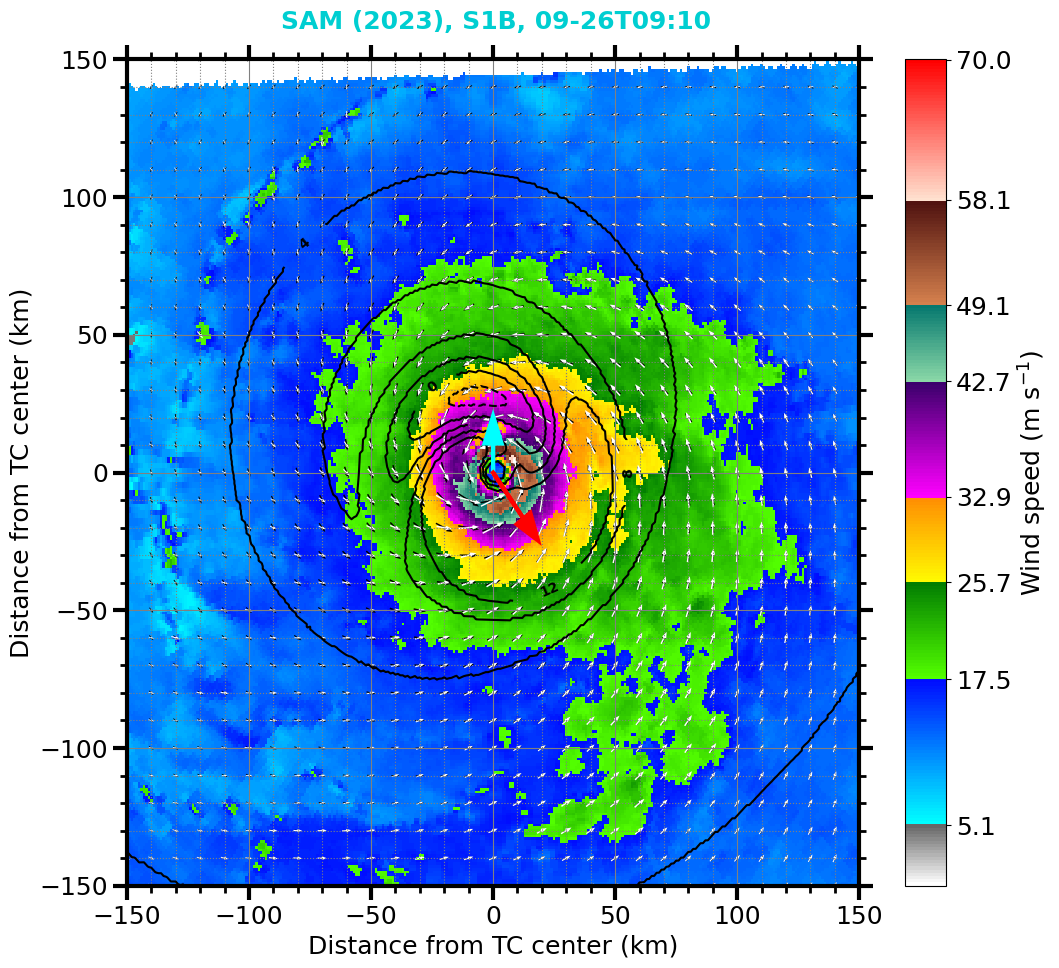

In [30]:
# Create figure with subplots
fig = plt.figure(figsize=(11, 10))
gs  = GridSpec(1, 1)
ax  = fig.add_subplot(gs[0, 0])

ax_lims2D  = 150

#####################
### SAR  B  SPEED ###
#####################
# ax.text(0.0, 1.03, '(b)', transform=ax.transAxes, fontsize=18, fontweight='bold', verticalalignment='bottom', horizontalalignment='left')
ax.text(0.211, 1.037, 'SAM (2023), S1B, {}'.format(np.datetime_as_string(case.time, unit='m')[5:]), transform = ax.transAxes, weight='bold', fontsize=18, c='darkturquoise')

# SAR wind speeds
im = ax.pcolormesh(x_ref / 1000, y_ref / 1000, wsc, cmap=cmap_cyclobs, vmin=vmin, vmax=vmax)
# # ZU12 inflow angle
ax.quiver(x_ref[::step, ::step] / 1000, y_ref[::step, ::step] / 1000, Uk25p[::step, ::step],  Vk25p[::step, ::step],  color='k',    **arrow_prms)
# K25 inflow angle
# ax.quiver(x_ref[::step, ::step] / 1000, y_ref[::step, ::step] / 1000, U_zu12[::step, ::step], V_zu12[::step, ::step], color='pink', **arrow_prms)
ax.quiver(x_ref[::step, ::step] / 1000, y_ref[::step, ::step] / 1000, U_zu12[::step, ::step], V_zu12[::step, ::step], color='w', **arrow_prms)
# 2. Ajouter les contours
cnt = ax.contour(x_ref / 1000, y_ref / 1000, kep_car_rot.sel(z=1010).w * 1e2, 
                 levels=[-4, 0, 4, 8, 12], 
                 colors='k',    # Couleur des lignes
                 linewidths=1.5,    # Épaisseur des lignes
                 zorder=5)          # Pour être au-dessus du pcolormesh
cnt_labels = ax.clabel(cnt, inline=True, fontsize=10)
[txt.set_fontweight('bold') for txt in cnt_labels]

# Motion vector
ax.arrow(
    0,                               # x_start: 150 km
    0,                               # y_start: 200 km
    0,                               # dx: 50 km (points right)
    float(case.speed * 3600 / 1000), # dy: 0 km (points top)
    head_width=7,                    # Width of the arrow head
    head_length=10,                  # Length of the arrow head
    fc='cyan',                           # Face color
    ec='cyan',                           # Edge color
    linewidth=3,
    zorder=10                         # Ensure it plots over the pcolormesh
)   
# Shear direction
ax.arrow(
    0,                                # x_start: 150 km
    0,                                # y_start: 200 km
    float(xs) / 1000,                # dx: 50 km (points right)
    float(ys) / 1000,                # dy: 0 km (horizontal)
    head_width=7,                    # Width of the arrow head
    head_length=10,                   # Length of the arrow head
    fc='r',                           # Face color
    ec='r',                           # Edge color
    linewidth=3,
    zorder=10                         # Ensure it plots over the pcolormesh
) 
# # Maximum Azim. Location
# ax.scatter(xm / 1000, ym / 1000, marker='x', s=150, c='white', linewidth=4)
# ax.scatter(xmk25p / 1000, ymk25p / 1000, marker='x', s=150, c='k', linewidth=4)

ax.set_xlim(-ax_lims2D, ax_lims2D);ax.set_ylim(-ax_lims2D, ax_lims2D)
ax.set_xlabel('Distance from TC center (km)')
ax.set_ylabel('Distance from TC center (km)')

# cbar = plt.colorbar(im1, ax=ax)
cbar = plt.colorbar(im, ax=ax, ticks=ticks_cyclobs)
cbar.set_ticklabels([round(tick, 1) for tick in ticks_cyclobs])
cbar.set_label(r'Wind speed (m s$^{-1}$)')

ax.minorticks_on()
ax.grid(which='major', linestyle='-', color='gray')
ax.grid(which='minor', linestyle=':', color='gray')
for spine in ax.spines.values():
    spine.set_linewidth(3)
    spine.set_edgecolor('black')
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
ax.tick_params(which='major', width=3, length=10, top=True, right=True)
ax.tick_params(which='minor', width=2, length=5, top=True, right=True)

# Final adjustments
plt.tight_layout()

# Save
if PRMS['sav_fgs']:
    plt.savefig(PTHS['sav_dir'] + 'Discussion_case.png', bbox_inches='tight')

In [21]:
float((kep_car_rot.sel(z=1010).w * 1e2).min()), float((kep_car_rot.sel(z=1010).w * 1e2).max())

(-4.95697929217922, 30.552810707271384)